# Visual-Inertial Robotics Mini Dataset

This notebook is meant to let students get familiar with the basic robotics visual pipeline.

1. Detect Shi-Tomasi corners in the first camera frame.
2. Track those corners using PyrLK optical flow.
3. Use known depth and camera calibration to back-project pixels into 3D.
4. Transform 3D points from the **optical frame** to the **body frame**, then to the **world frame**.

The dataset is synthetic so all variables are known and easy to verify.


In [5]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


c:\Users\User\Downloads\ACMAI-CV-Workshop-26\.venv\Scripts\python.exe: No module named pip


In [6]:
from pathlib import Path
import csv
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 5)

DATA_DIR = Path(".")
FRAME_DIR = DATA_DIR / "frames"
GT_DIR = DATA_DIR / "ground_truth"


## Load calibration and known frame transforms

In [7]:
with open(DATA_DIR / "calibration.json") as f:
    calib = json.load(f)

K = np.array(calib["K"], dtype=float)
R_optical_body = np.array(calib["R_optical_body"], dtype=float)
R_body_optical = np.array(calib["R_body_optical"], dtype=float)

print("K =\n", K)
print("\nR_optical_body =\n", R_optical_body)
print("\nR_body_optical =\n", R_body_optical)
print("\nBody frame:", calib["body_frame"])
print("Optical frame:", calib["optical_frame"])


K =
 [[420.   0. 320.]
 [  0. 420. 240.]
 [  0.   0.   1.]]

R_optical_body =
 [[ 0. -1.  0.]
 [ 0.  0. -1.]
 [ 1.  0.  0.]]

R_body_optical =
 [[ 0.  0.  1.]
 [-1.  0.  0.]
 [ 0. -1.  0.]]

Body frame: X forward, Y left, Z up
Optical frame: X right, Y down, Z forward


In [8]:
def read_gray(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img

def show_gray(img, title=""):
    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_bgr(img, title=""):
    plt.figure()
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def load_body_pose(frame_idx):
    with open(GT_DIR / "body_poses_world.csv", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if int(row["frame"]) == frame_idx:
                p_wb = np.array([float(row["p_wb_x"]), float(row["p_wb_y"]), float(row["p_wb_z"])])
                R_wb = np.array([
                    [float(row["R_wb_00"]), float(row["R_wb_01"]), float(row["R_wb_02"])],
                    [float(row["R_wb_10"]), float(row["R_wb_11"]), float(row["R_wb_12"])],
                    [float(row["R_wb_20"]), float(row["R_wb_21"]), float(row["R_wb_22"])],
                ])
                return R_wb, p_wb
    raise ValueError(f"No pose found for frame {frame_idx}")

def load_measurements(frame_idx):
    rows = []
    with open(GT_DIR / "measurements.csv", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if int(row["frame"]) == frame_idx:
                rows.append(row)
    return rows


## Part 1: View the first frame and ground truth

Ground-truth visualizations are provided only for comparison. Your pipeline should begin from the raw frame.


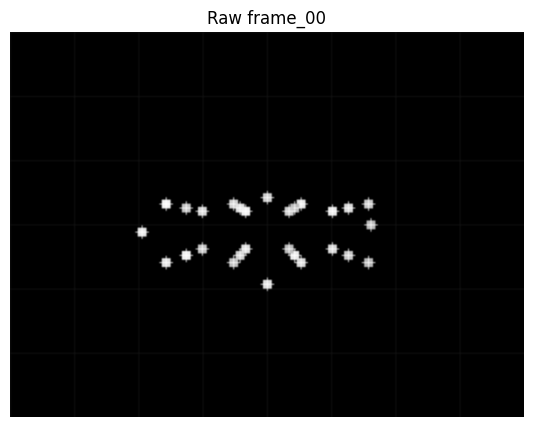

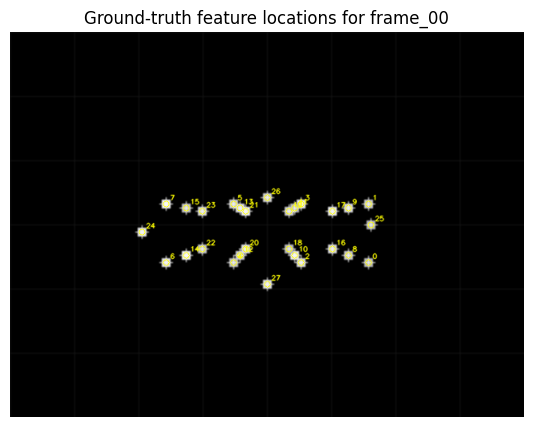

In [9]:
img0 = read_gray(FRAME_DIR / "frame_00.png")
show_gray(img0, "Raw frame_00")

gt0 = cv2.imread(str(GT_DIR / "gt_points_frame_00.png"))
show_bgr(gt0, "Ground-truth feature locations for frame_00")


## Part 2: Detect Shi-Tomasi corners

Fill in the OpenCV call. The output should be an array shaped roughly like `(N, 1, 2)`.


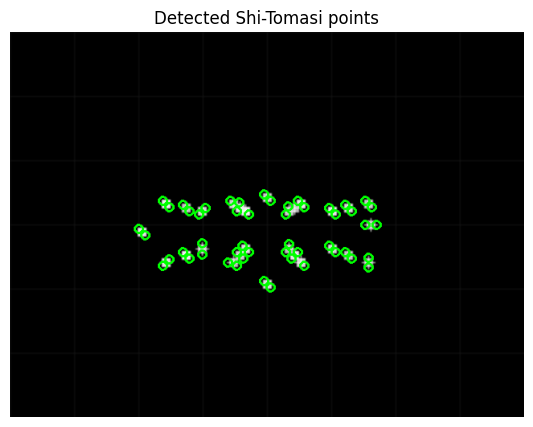

In [10]:
# TODO: call cv2.goodFeaturesToTrack(...)
# Suggested parameters:
#   maxCorners=80
#   qualityLevel=0.01
#   minDistance=10
#   blockSize=5

p0 = cv2.goodFeaturesToTrack(img0, maxCorners=80, qualityLevel=0.01, minDistance=10, blockSize=5)

vis = cv2.cvtColor(img0, cv2.COLOR_GRAY2BGR)

if p0 is None:
    print("TODO: fill in cv2.goodFeaturesToTrack.")
else:
    for pt in p0.reshape(-1, 2):
        x, y = pt.astype(int)
        cv2.circle(vis, (x, y), 5, (0, 255, 0), 2)

show_bgr(vis, "Detected Shi-Tomasi points")

## Part 3: Track features with PyrLK

Track the Shi-Tomasi points through the next frames.


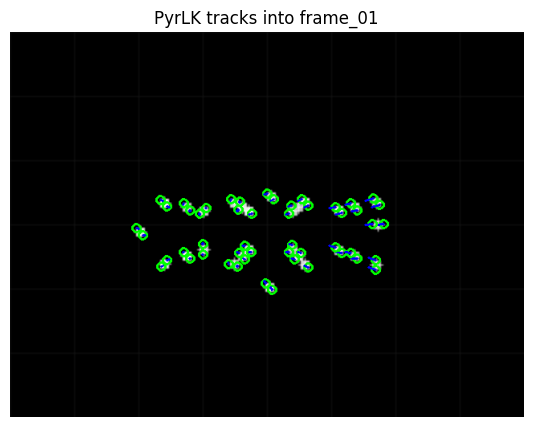

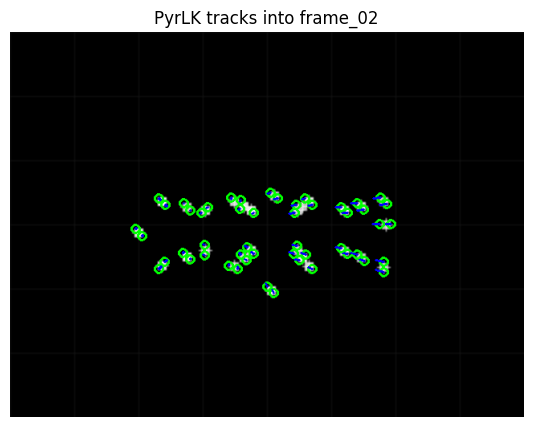

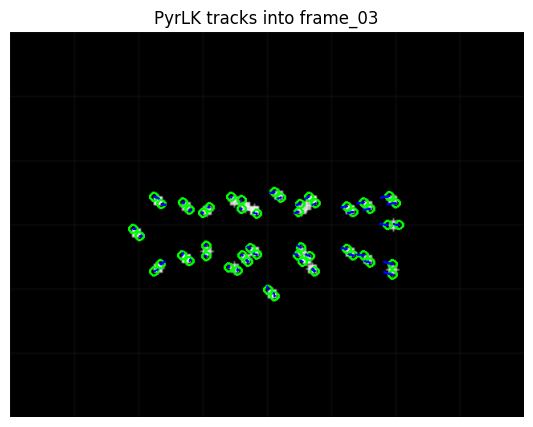

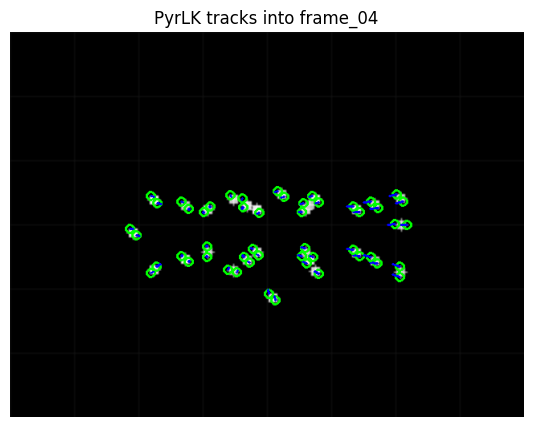

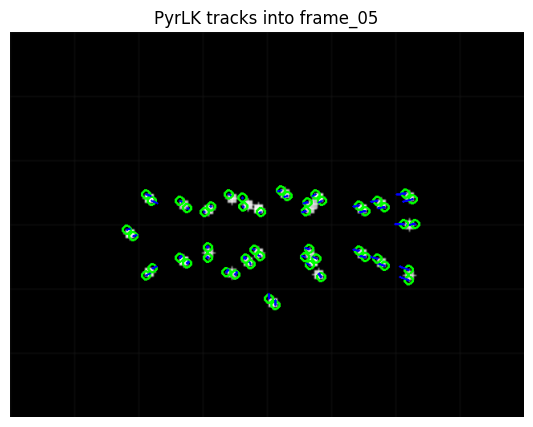

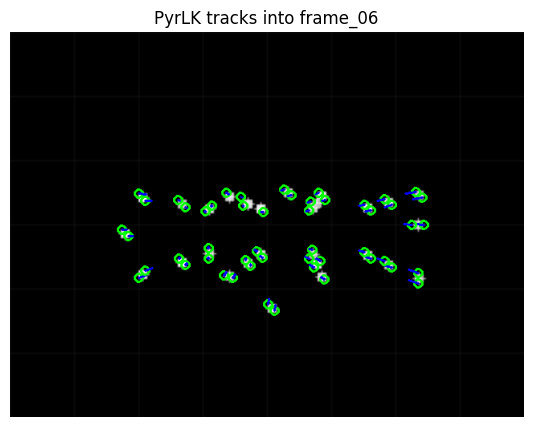

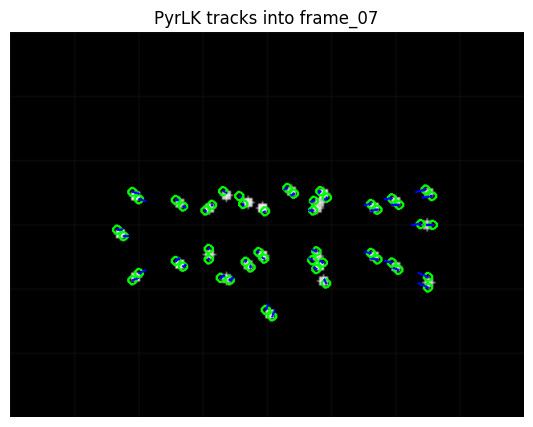

In [11]:
tracked_by_frame = {}

if p0 is None:
    print("Run the Shi-Tomasi TODO cell first.")
else:
    prev_img = img0.copy()
    prev_pts = p0.copy()
    tracked_by_frame[0] = prev_pts.copy()

    for frame_idx in range(1, 8):
        next_img = read_gray(FRAME_DIR / f"frame_{frame_idx:02d}.png")

        next_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_img, next_img, prev_pts, None)

        if next_pts is None or status is None:
            print("TODO: fill in cv2.calcOpticalFlowPyrLK.")
            break

        good_old = prev_pts[status.reshape(-1) == 1]
        good_new = next_pts[status.reshape(-1) == 1]

        tracked_by_frame[frame_idx] = good_new.reshape(-1, 1, 2)

        vis = cv2.cvtColor(next_img, cv2.COLOR_GRAY2BGR)
        for old_pt, new_pt in zip(good_old.reshape(-1, 2), good_new.reshape(-1, 2)):
            x0, y0 = old_pt.astype(int)
            x1, y1 = new_pt.astype(int)

            cv2.circle(vis, (x1, y1), 5, (0, 255, 0), 2)
            cv2.line(vis, (x0, y0), (x1, y1), (255, 0, 0), 2)

        show_bgr(vis, f"PyrLK tracks into frame_{frame_idx:02d}")

        prev_img = next_img
        prev_pts = good_new.reshape(-1, 1, 2)

## Part 4: Back-project one known pixel using known depth

For simplicity, the dataset gives known depth for every ground-truth feature. This lets you practice the frame transformation step without needing stereo or triangulation.

Projection model:

$$
\mathbf{x}_o = Z K^{-1}\begin{bmatrix}u \\ v \\ 1\end{bmatrix}
$$

where $\mathbf{x}_o$ is the 3D point in the optical frame.


In [12]:
def pixel_depth_to_optical(u, v, depth_z, K):
    pixel_h = np.array([u, v, 1.0])

    ray = np.linalg.inv(K) @ pixel_h

    point_optical = ray * depth_z

    return point_optical

# Use a known measurement from frame 0.
rows0 = load_measurements(frame_idx=0)
example = rows0[0]

u = float(example["u"])
v = float(example["v"])
depth_z = float(example["depth_z_optical"])

point_optical = pixel_depth_to_optical(u, v, depth_z, K)

print("Example pixel:", (u, v))
print("Known optical depth:", depth_z)
print("Computed optical-frame 3D point:", point_optical)
print("Ground-truth optical-frame 3D point:",
      [float(example["optical_x"]), float(example["optical_y"]), float(example["optical_z"])])

Example pixel: (446.0, 287.25)
Known optical depth: 4.0
Computed optical-frame 3D point: [1.2  0.45 4.  ]
Ground-truth optical-frame 3D point: [1.2, 0.45, 4.0]


## Part 5: Optical frame → body frame → world frame

Known transforms:

$$
\mathbf{x}_b = R_{bo}\mathbf{x}_o
$$

$$
\mathbf{x}_w = R_{wb}\mathbf{x}_b + \mathbf{p}_{wb}
$$

where:
- $R_{bo}$ transforms optical coordinates into body coordinates.
- $R_{wb}$ and $\mathbf{p}_{wb}$ are the known robot body pose in the world.


In [13]:
def optical_to_body(point_optical):
    point_body = R_body_optical @ point_optical
    return point_body

def body_to_world(point_body, frame_idx):
    R_wb, p_wb = load_body_pose(frame_idx)

    point_world = R_wb @ point_body + p_wb
    return point_world

if point_optical is None:
    print("Complete pixel_depth_to_optical first.")
else:
    point_body = optical_to_body(point_optical)
    point_world = body_to_world(point_body, frame_idx=0)

    print("Computed body-frame point:", point_body)
    print("Ground-truth body-frame point:",
          [float(example["body_x"]), float(example["body_y"]), float(example["body_z"])])

    print("\nComputed world-frame point:", point_world)
    print("Ground-truth world-frame point:",
          [float(example["world_x"]), float(example["world_y"]), float(example["world_z"])])

Computed body-frame point: [ 4.   -1.2  -0.45]
Ground-truth body-frame point: [4.0, -1.2, -0.45]

Computed world-frame point: [ 4.   -1.2  -0.45]
Ground-truth world-frame point: [4.0, -1.2, -0.45]
